# Clustering



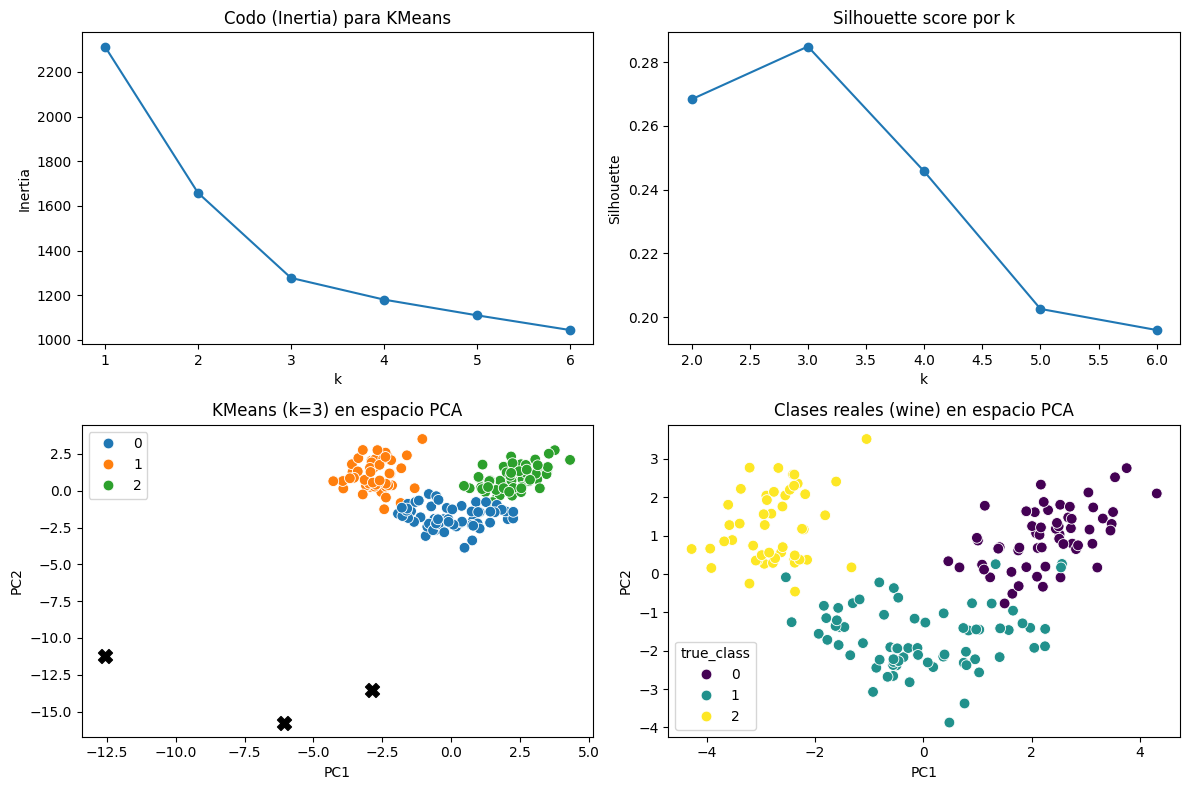

KMeans elegido k=3 -> silhouette_score = 0.285

Matriz de confusión (true_class vs cluster):
              cluster_0  cluster_1  cluster_2
true_class_0          0          0         59
true_class_1         65          3          3
true_class_2          0         48          0

DBSCAN encontró 0 clusters (label -1 = ruido).


In [1]:
# Ejemplo completo de clustering usando el dataset "wine"

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Cargar dataset y crear DataFrame
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='true_class')
df = pd.concat([X, y], axis=1)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducción a 2D para visualización
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)
df_vis = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_vis['true_class'] = y

# Determinar k con el método del codo (elbow) y calcular silhouette para k>=2
inertias = []
sil_scores = []
ks = range(1, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        sil_scores.append(silhouette_score(X_scaled, km.labels_))
    else:
        sil_scores.append(np.nan)

# Elegir k=3 (conocimiento previo del dataset) y ajustar KMeans
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=0, n_init=10).fit(X_scaled)
labels_km = kmeans.labels_

# Score de silhouette
sil = silhouette_score(X_scaled, labels_km)

# Matriz de confusión entre clases reales y clusters (puede necesitar relabeling)
cm = pd.DataFrame(confusion_matrix(y, labels_km),
                  index=[f"true_{i}" for i in data.target_names],
                  columns=[f"cluster_{i}" for i in range(k_opt)])

# DBSCAN como alternativa (parámetros ejemplo)
db = DBSCAN(eps=0.9, min_samples=5).fit(X_scaled)
labels_db = db.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)

# Visualizaciones
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(ks, inertias, '-o')
plt.title('Codo (Inertia) para KMeans')
plt.xlabel('k')
plt.ylabel('Inertia')

plt.subplot(2, 2, 2)
plt.plot(ks, sil_scores, '-o')
plt.title('Silhouette score por k')
plt.xlabel('k')
plt.ylabel('Silhouette')

plt.subplot(2, 2, 3)
sns.scatterplot(x='PC1', y='PC2', hue=labels_km, palette='tab10', data=df_vis, legend='full', s=60)
centers_pca = pca.transform(scaler.transform(pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)))
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', s=100, marker='X', label='centros')
plt.title(f'KMeans (k={k_opt}) en espacio PCA')

plt.subplot(2, 2, 4)
sns.scatterplot(x='PC1', y='PC2', hue='true_class', palette='viridis', data=df_vis, legend='full', s=60)
plt.title('Clases reales (wine) en espacio PCA')

plt.tight_layout()
plt.show()

# Resultados resumidos
print(f"KMeans elegido k={k_opt} -> silhouette_score = {sil:.3f}")
print("\nMatriz de confusión (true_class vs cluster):")
print(cm)
print(f"\nDBSCAN encontró {n_clusters_db} clusters (label -1 = ruido).")

### Silhouette score

El silhouette score mide qué tan bien está asignado un punto a su clúster comparando la distancia media dentro del clúster propio y la distancia media al clúster más cercano. Para un punto i:

s(i) = (b(i) - a(i)) / max(a(i), b(i))

- a(i): distancia media de i a otros puntos de su propio clúster (cohesión).
- b(i): mínima distancia media de i a todos los puntos de cualquier otro clúster (separación).

**Interpretación:**
- s ≈ 1: buena asignación (muy cohesivo y bien separado).
- s ≈ 0: punto en la frontera entre clústeres.
- s < 0: posible mala asignación (más cercano a otro clúster).

El silhouette score del conjunto suele ser el promedio de s(i) sobre todos los puntos.

## Clustering jerarquico

La agrupación jerárquica (Hierarchical Clustering o Agglomerative Clustering) es un tipo de aprendizaje no supervisado que busca construir una jerarquía de agrupaciones (clusters), donde la clasificación de un punto de datos no depende de una solución final predefinida, sino de su posición dentro de una estructura de árbol.

A diferencia de los métodos de "agrupación plana" (flat clustering) como K-Means, que dividen los datos en un conjunto de clusters sin relacionarlos entre sí, la agrupación jerárquica crea una jerarquía de clusters que puede visualizarse a través de un dendrograma.

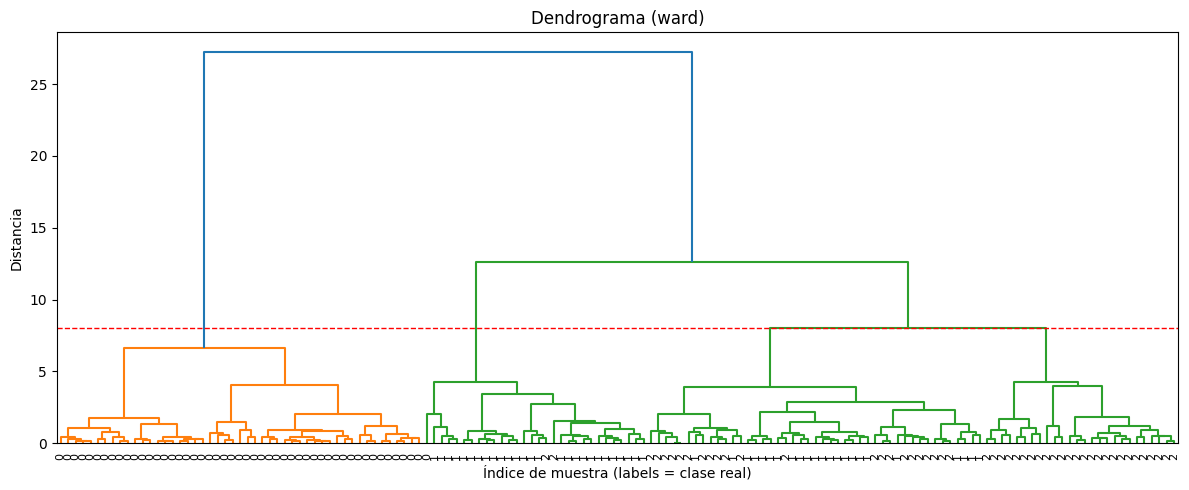

Silhouette (fcluster) para 3 clusters: 0.447

Conteo por cluster (fcluster):
0    49
1    30
2    71
Name: count, dtype: int64

Crosstab (true_class vs cluster):
cluster_h    0   1   2
true_class            
0           49   1   0
1            0  27  23
2            0   2  48


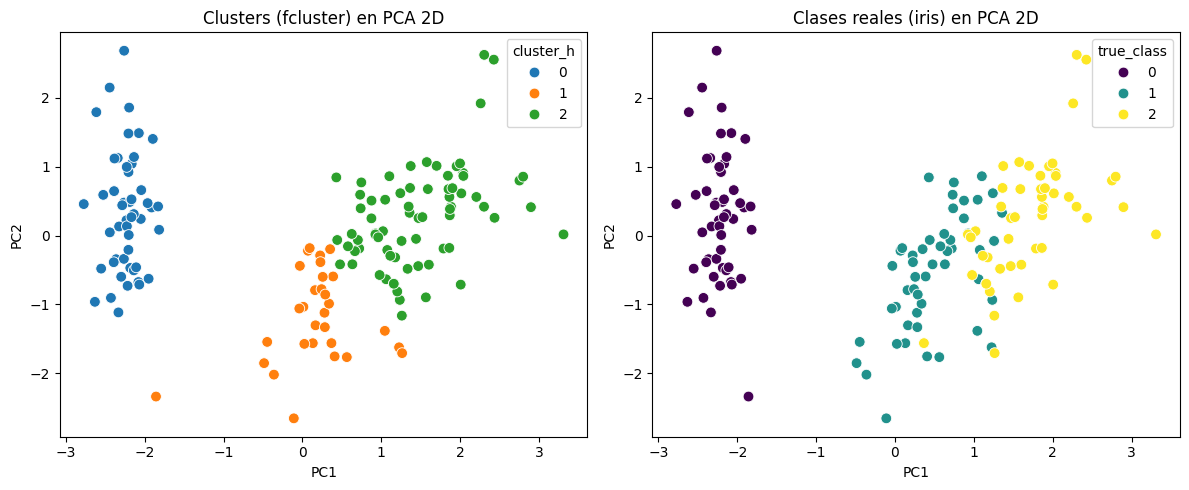

In [2]:
# Clustering jerárquico completo (autocontenido) con dendrograma — dataset: iris

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Cargar datos
iris = load_iris()
X_h = pd.DataFrame(iris.data, columns=iris.feature_names)
y_true = pd.Series(iris.target, name='true_class')

# Escalado
scaler_h = StandardScaler()
X_scaled_h = scaler_h.fit_transform(X_h)

# Matriz de linkage (Ward)
linkage_matrix = linkage(X_scaled_h, method='ward')

# Dendrograma
plt.figure(figsize=(12, 5))
dn = dendrogram(linkage_matrix, labels=y_true.values, 
                leaf_rotation=90, leaf_font_size=8, color_threshold=None)
plt.title('Dendrograma (ward)')
plt.xlabel('Índice de muestra (labels = clase real)')
plt.ylabel('Distancia')
# línea de corte para 3 clusters (opcional, basada en maxclust)
plt.axhline(y=8, color='r', linestyle='--', lw=1)  # ajustar si se desea otra separación visual
plt.tight_layout()
plt.show()

# Extraer clusters cortando en número de clusters deseado
n_clusters = 3
labels_h = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust') - 1  # pasar a 0-based

# Alternativa con AgglomerativeClustering (para obtener mismo n_clusters directamente)
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_agg = agg.fit_predict(X_scaled_h)

# Evaluación rápida
sil_h = silhouette_score(X_scaled_h, labels_h) if len(np.unique(labels_h)) > 1 else np.nan
print(f"Silhouette (fcluster) para {n_clusters} clusters: {sil_h:.3f}")

# Conteo por cluster y matriz de confusión vs clases reales
print("\nConteo por cluster (fcluster):")
print(pd.Series(labels_h).value_counts().sort_index())

print("\nCrosstab (true_class vs cluster):")
print(pd.crosstab(y_true, labels_h, rownames=['true_class'], colnames=['cluster_h']))

# Visualización en 2D usando PCA
pca_h = PCA(n_components=2, random_state=0)
X_pca_h = pca_h.fit_transform(X_scaled_h)
df_vis_h = pd.DataFrame(X_pca_h, columns=['PC1', 'PC2'])
df_vis_h['cluster_h'] = labels_h
df_vis_h['cluster_agg'] = labels_agg
df_vis_h['true_class'] = y_true.values

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_vis_h, x='PC1', y='PC2', hue='cluster_h', palette='tab10', s=60)
plt.title('Clusters (fcluster) en PCA 2D')
plt.legend(title='cluster_h', loc='best')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_vis_h, x='PC1', y='PC2', hue='true_class', palette='viridis', s=60)
plt.title('Clases reales (iris) en PCA 2D')
plt.legend(title='true_class', loc='best')

plt.tight_layout()
plt.show()

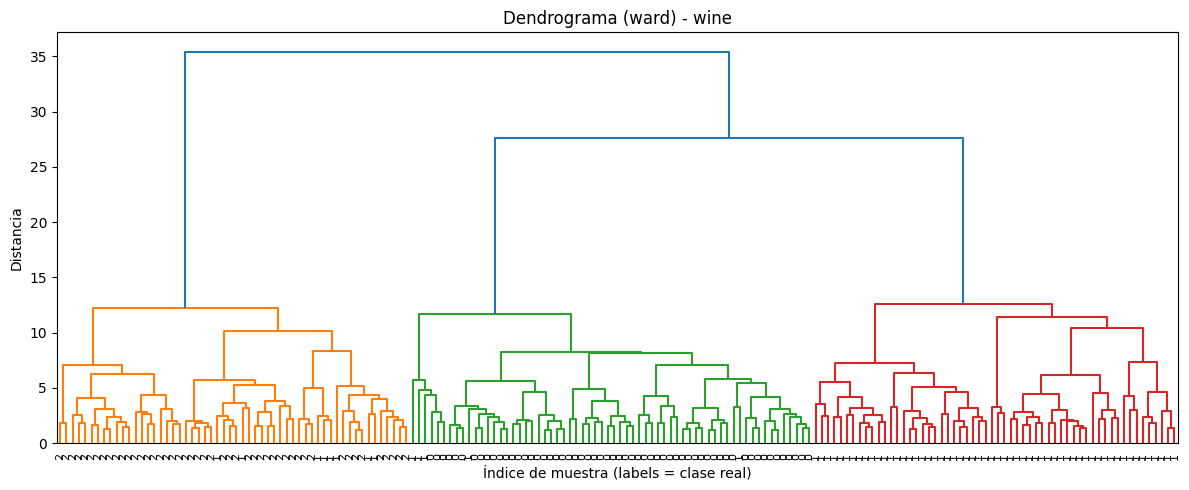

Silhouette (fcluster) k=3: 0.277
Silhouette (Agglomerative) k=3: 0.277

Crosstab (true_class vs cluster_fcluster):
cluster_h    0   1   2
true_class            
0            0  59   0
1            8   5  58
2           48   0   0

Crosstab (true_class vs cluster_agg):
cluster_agg   0   1   2
true_class             
0             0   0  59
1            58   8   5
2             0  48   0


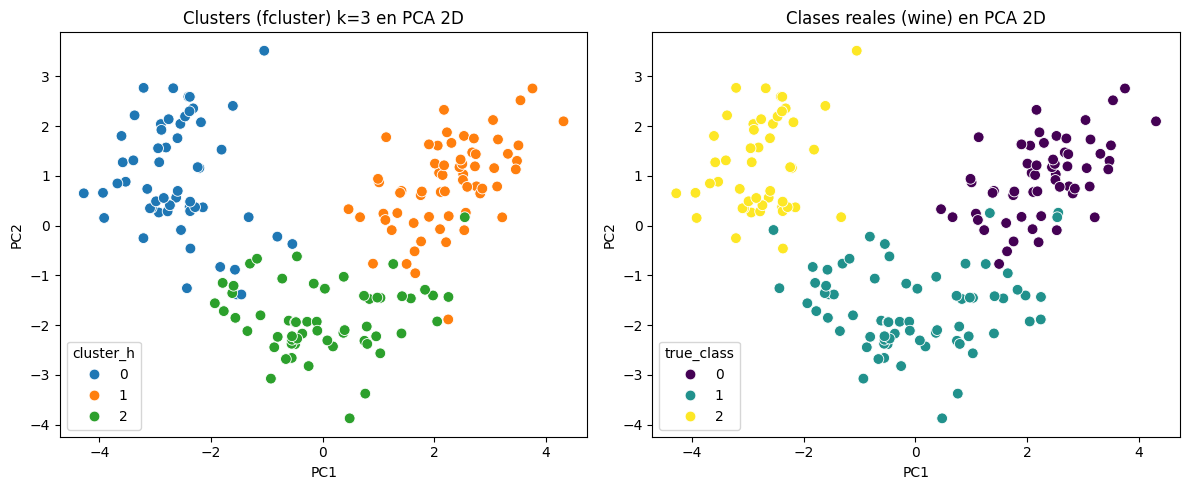

In [3]:
# Clustering jerárquico autocontenido con el dataset wine

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Cargar dataset y crear DataFrame
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='true_class')
X = df.drop(columns='true_class')
y = df['true_class'].values

# Escalado
scaler_w = StandardScaler()
X_scaled_w = scaler_w.fit_transform(X)

# Linkage (Ward) y dendrograma
linkage_matrix_w = linkage(X_scaled_w, method='ward')
plt.figure(figsize=(12, 5))
dn_w = dendrogram(linkage_matrix_w, labels=y, leaf_rotation=90, leaf_font_size=8, color_threshold=None)
plt.title('Dendrograma (ward) - wine')
plt.xlabel('Índice de muestra (labels = clase real)')
plt.ylabel('Distancia')
plt.axhline(y=50, color='r', linestyle='--', lw=1)  # ajustar si se desea otro corte visual
plt.tight_layout()
plt.show()

# Cortar el dendrograma para obtener n_clusters
n_clusters_w = 3
labels_h_w = fcluster(linkage_matrix_w, t=n_clusters_w, criterion='maxclust') - 1  # 0-based

# Alternativa: AgglomerativeClustering para obtener etiquetas directamente
agg_w = AgglomerativeClustering(n_clusters=n_clusters_w, linkage='ward')
labels_agg_w = agg_w.fit_predict(X_scaled_w)

# Evaluación: silhouette y crosstabs
sil_h_w = silhouette_score(X_scaled_w, labels_h_w) if len(set(labels_h_w)) > 1 else np.nan
sil_agg_w = silhouette_score(X_scaled_w, labels_agg_w) if len(set(labels_agg_w)) > 1 else np.nan

print(f"Silhouette (fcluster) k={n_clusters_w}: {sil_h_w:.3f}")
print(f"Silhouette (Agglomerative) k={n_clusters_w}: {sil_agg_w:.3f}\n")

print("Crosstab (true_class vs cluster_fcluster):")
print(pd.crosstab(y, labels_h_w, rownames=['true_class'], colnames=['cluster_h']))

print("\nCrosstab (true_class vs cluster_agg):")
print(pd.crosstab(y, labels_agg_w, rownames=['true_class'], colnames=['cluster_agg']))

# Visualización 2D con PCA
X_pca_w = pca.transform(X_scaled_w)  # `pca` ya existe en el notebook (n_components=2)
df_vis_w = pd.DataFrame(X_pca_w, columns=['PC1', 'PC2'])
df_vis_w['cluster_h'] = labels_h_w
df_vis_w['cluster_agg'] = labels_agg_w
df_vis_w['true_class'] = y

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_vis_w, x='PC1', y='PC2', hue='cluster_h', palette='tab10', s=60)
plt.title(f'Clusters (fcluster) k={n_clusters_w} en PCA 2D')
plt.legend(title='cluster_h', loc='best')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_vis_w, x='PC1', y='PC2', hue='true_class', palette='viridis', s=60)
plt.title('Clases reales (wine) en PCA 2D')
plt.legend(title='true_class', loc='best')

plt.tight_layout()
plt.show()

### Cluster jerarquico sobre datos de pacientes
El Heart Disease Dataset de la UCI Machine Learning Repository, contiene información clínica de pacientes y es ideal para este tipo de análisis.

- **Fuente**: [UCI Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)
- **Características**: Edad, sexo, presión arterial, colesterol, resultados de ECG, etc.
- **Objetivo**: Agrupar pacientes en subgrupos basados en sus características fisiológicas y clínicas, sin usar la etiqueta de diagnóstico (aprendizaje no supervisado).

Datos cargados: 303 muestras, 11 características


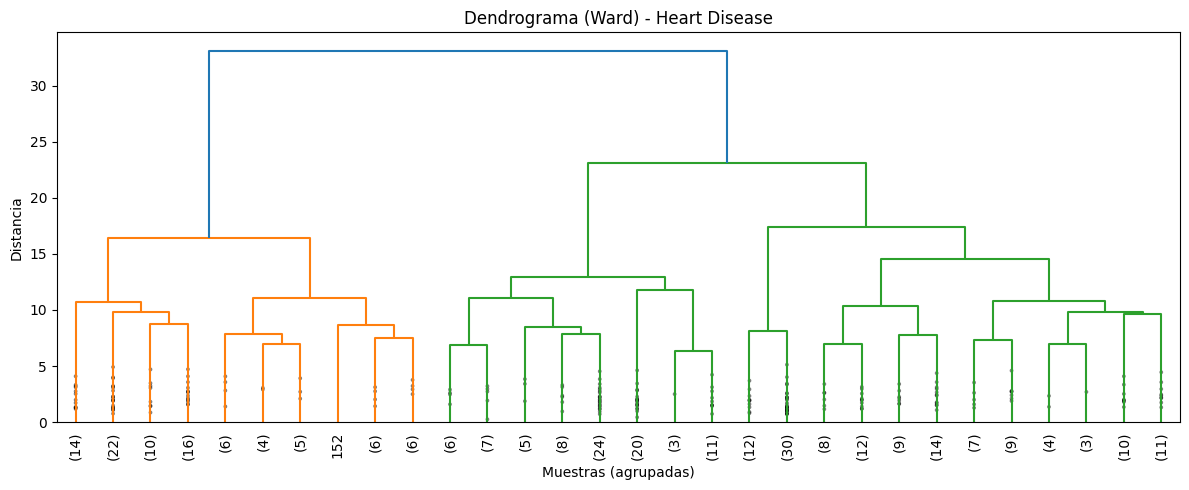

Silhouette score (k=3): 0.133

Tamaño por cluster:
cluster
1     90
2     84
3    129
Name: count, dtype: int64

Medias por cluster:
           age   sex    cp  trestbps    chol  thalach  exang  oldpeak  slope  \
cluster                                                                        
1        56.61  0.80  3.88    134.41  258.69   131.84   0.87     1.82   1.97   
2        55.19  0.07  3.00    129.63  254.07   153.74   0.19     0.49   1.40   
3        52.43  0.99  2.76    131.13  233.52   159.31   0.04     0.86   1.47   

           ca  thal  
cluster              
1        1.16  6.09  
2        0.36  3.14  
3        0.52  4.80  


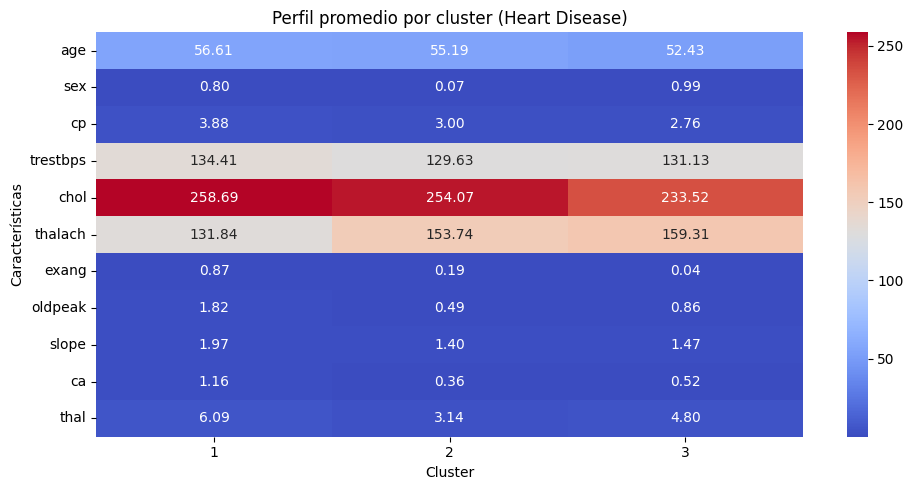

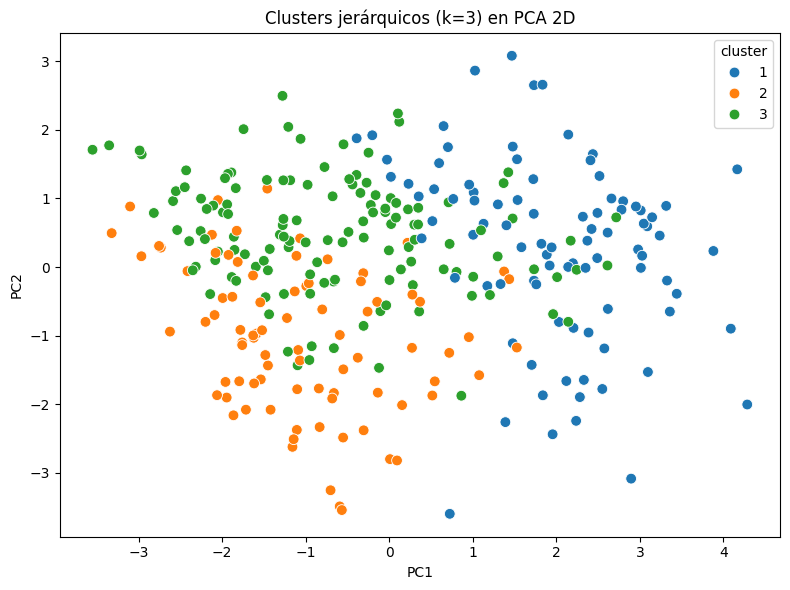

In [4]:
# Ejemplo autocontenido: Clustering jerárquico sobre Heart Disease (UCI)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1) Cargar datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
df_raw = pd.read_csv(url, names=column_names, na_values='?')

# 2) Imputación y limpieza
imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df_raw), columns=df_raw.columns)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna().reset_index(drop=True)

# 3) Seleccionar características (excluir 'target')
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X = df[features].copy()

print(f"Datos cargados: {X.shape[0]} muestras, {X.shape[1]} características")

# 4) Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5) Linkage (Ward) y dendrograma
linkage_matrix = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Dendrograma (Ward) - Heart Disease')
plt.xlabel('Muestras (agrupadas)')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

# 6) Cortar para obtener clusters
n_clusters = 3
cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
df['cluster'] = cluster_labels

# 7) Evaluación y resumen
sil = silhouette_score(X_scaled, cluster_labels) if len(np.unique(cluster_labels)) > 1 else np.nan
print(f"Silhouette score (k={n_clusters}): {sil:.3f}")
print('\nTamaño por cluster:')
print(df['cluster'].value_counts().sort_index())

cluster_summary = df.groupby('cluster')[features].mean()
print('\nMedias por cluster:')
print(cluster_summary.round(2))

# Heatmap de medias (estandarizamos las medias para visualización)
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_summary.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Perfil promedio por cluster (Heart Disease)')
plt.ylabel('Características')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# PCA 2D para visualización de clusters
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)
df_vis = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_vis['cluster'] = cluster_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='cluster', palette='tab10', s=60)
plt.title(f'Clusters jerárquicos (k={n_clusters}) en PCA 2D')
plt.legend(title='cluster')
plt.tight_layout()
plt.show()

- Cluster 1: Características mixtas, tal vez con problemas de estrés inducido.
- Cluster 2: Pacientes más jóvenes con alta frecuencia cardíaca → posiblemente con dolor torácico no grave.
- Cluster 3: Pacientes mayores, con menor frecuencia cardíaca → posible riesgo cardiovascular alto.